## NMD Models: Deposit Decay Model

This notebook shows how to build the runoff profile for core deposit with 2 difference methodologies.

| Method | Description |
|---|---|
| Historical Runoff | Using the 12-months runoff rates from observed data and optimize seed rate at month 13 onward |
| Static Replicating Portfolio | Finding weights of fixed-maturity instruments where minimize tracking error and deposit rate |

### Input from other components 
| Input | From | Use for |
|---|---|---|
| `hazard_rates` | 02_survival_decay — `compute_snapshot_hazard_rates()` | Method 1: Historical Runoff |
| `core` (Deposit balance series) | 03_stable_nonstable | Method 1: Compute Weighted Average Life (WAL), Method 2: Transform weights to MB |
| `beta` (pass-through) | 04_deposit_rate_model | Method 1: Compute core balance |

### Core Balance

```
Core balance = total_balance × stable_pct × (1 - beta)
```
where;
- `stable_pct` is the stable percentage that is a core balance
- `(1 - beta)` is the sticky portion that is not immediately reprice (Behaviourally sticky)

In [1]:
# Set autoreload
%load_ext autoreload
%autoreload 2

In [14]:
# Import libraries
import warnings
import pandas as pd
import pickle
import matplotlib.pyplot as plt
import sys; sys.path.insert(0, "..")

from matplotlib.ticker import PercentFormatter
from src.deposit_decay_model import optimize_seed_rate, build_irrbb_buckets, build_yield_curve, static_replicating_portfolio
from src.plot_function import plot_hist_runoff, plot_replicate_port

pd.options.display.float_format = "{:.3f}".format
warnings.simplefilter(action = "ignore", category = pd.errors.PerformanceWarning)

In [3]:
# Load Data
df = pd.read_parquet(
    '../data/raw/nmd_data.parquet',
    engine = "pyarrow"
)

# Extract information
balance = df["balance"]
deposit_rate = df["deposit_rate"]
market_rate = df["market_rate"]

# Show
print("=" * 60)
print(f"{"Observations":<{20}}: {len(df)}")
print(f"{"Date range":<{20}}: {df.index[0].date()} to {df.index[-1].date()}")
print("=" * 60)

Observations        : 150
Date range          : 2012-01-31 to 2024-06-30


In [4]:
# Import related models
# Import hazard rate
with open("../model/hazard_rate.pkl", "rb") as file:
    hazard_rates = pickle.load(file)

# Import model (HP Model)
with open("../model/hp_model.pkl", "rb") as file:
    hp_result = pickle.load(file)

# Import beta model
with open("../model/beta_model.pkl", "rb") as file:
    beta_result = pickle.load(file)

In [5]:
# Get upstream parameters
N_PERIOD = 24
hist_runoff = hazard_rates.dropna().iloc[:N_PERIOD].values
stable_pct, core_series = hp_result["stable_pct"], hp_result["core"]
beta = beta_result["beta"]

# Core balance = total × stable_pct × (1 - beta)
total_balance_latest = float(balance.iloc[-1])
core_balance_latest = total_balance_latest * stable_pct * (1 - beta)

# Show
print("=" * 60)
print(f"{"Total balance (latest)":<{30}}: {total_balance_latest:,.2f}")
print(f"{"Stable":<{30}}: {stable_pct:.2%}")
print(f"{"Beta (Pass-through rate)":<{30}}: {beta:.2%}")
print(f"{"Core % of total":<{30}}: {stable_pct * (1 - beta):.2%}")
print(f"{"Core balance (latest)":<{30}}: {core_balance_latest:,.2f}")
print(f"{"Historical runoff (12m avg)":<{30}}: {hist_runoff.mean():.2%}")
print(f"{"Historical runoff range":<{30}}: {hist_runoff.min():.2%} - {hist_runoff.max():.2%}")
print("=" * 60)

Total balance (latest)        : 5,039.65
Stable                        : 96.36%
Beta (Pass-through rate)      : 20.72%
Core % of total               : 76.40%
Core balance (latest)         : 3,850.14
Historical runoff (12m avg)   : 0.63%
Historical runoff range       : 0.10% - 1.02%


In [6]:
# Historical runoff proflie with optimized Seed Rate
opt_result = optimize_seed_rate(
    hist_runoff = hist_runoff,
    max_wal_years = 5.0,
    max_core_pct = 0.90,
    n_months = 60,
    n_period = N_PERIOD
)

# Result
print("=" * 60)
print(f"{"Converged":<{25}}: {opt_result['converged']} (WAL <= 5 Years and %Core <= 90%)")
print(f"{"Long run const":<{25}}: {opt_result['seed_rate']:.2%}")
print(f"{"Weighted Average Life":<{25}}: {opt_result['wal_years']:.2f} Years")
print(f"{"Core at year 5":<{25}}: {opt_result['core_pct']:.2%}")
print("=" * 60)

Converged                : True (WAL <= 5 Years and %Core <= 90%)
Long run const           : 2.87%
Weighted Average Life    : 2.84 Years
Core at year 5           : 30.10%


In [7]:
# IRRBB Repricing buckets
irrbb_buckets = build_irrbb_buckets(
    profile = opt_result["profile"],
    core_balance_mb = core_balance_latest
)

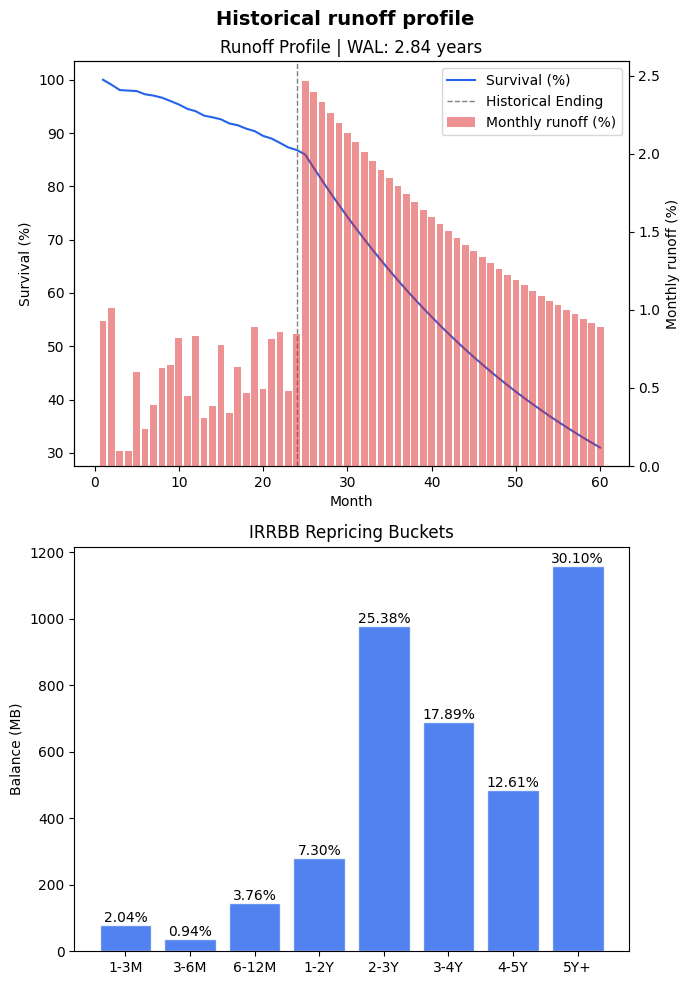

In [8]:
# Plot historical runoff proflie
plot_hist_runoff(
    profile = opt_result["profile"],
    irrbb_buckets = irrbb_buckets
)

In [9]:
# Build balance profile
balance_profile = opt_result["profile"]["survival_prob"] * core_balance_latest

# Update dictionary
opt_result["core_balance"] = core_balance_latest
opt_result["balance_profile"] = balance_profile

# Export
with open("../model/runoff_model.pkl", "wb") as file:
    pickle.dump(opt_result, file)

In [10]:
# Static replicating portfolio
rep_result = static_replicating_portfolio(
    deposit_rate = deposit_rate,
    market_rate = market_rate,
    core_balance_mb = core_balance_latest,
    tenors_years = [0.25, 0.5, 1, 2, 3],
    max_wal_years = 5.0,
    max_weight_per_tenor = 0.50
)

# Result
print("=" * 60)
print(f"{"Tracking error":<{20}}: {rep_result['tracking_error']:.2%}")
print(f"{"Margin":<{20}}: {rep_result['margin']:.2%}")
print("=" * 60)

Tracking error      : 0.42%
Margin              : 3.00%


In [18]:
# Build replicating portfolio table
weights = rep_result["weights"].values
yield_curve = rep_result["yield_curve"]
tenor_labels = yield_curve.columns.tolist()

dep = deposit_rate.reindex(yield_curve.index)
portfolio_yield = yield_curve.values @ weights

# To DataFrame
rep_table = pd.DataFrame(index = yield_curve.index)
rep_table["client_rate"] = dep.values
for label, col in zip(tenor_labels, yield_curve.values.T):
    rep_table[label] = col
rep_table["portfolio_yield"] = portfolio_yield
rep_table["margin"] = (portfolio_yield - dep.values)

# Export
with open("../model/replicating_weights.pkl", "wb") as file:
    pickle.dump(weights, file)

# Result
rep_table.head(5)

,client_rate,3M,6M,1Y,2Y,3Y,portfolio_yield,margin
date,,,,,,,,
2012-01-31,0.011,0.037,0.041,0.045,0.049,0.052,0.047,0.036
2012-02-29,0.011,0.031,0.037,0.045,0.048,0.049,0.045,0.034
2012-03-31,0.011,0.030,0.034,0.041,0.045,0.048,0.043,0.032
2012-04-30,0.012,0.033,0.038,0.045,0.045,0.047,0.044,0.033
2012-05-31,0.010,0.023,0.032,0.040,0.043,0.044,0.040,0.030


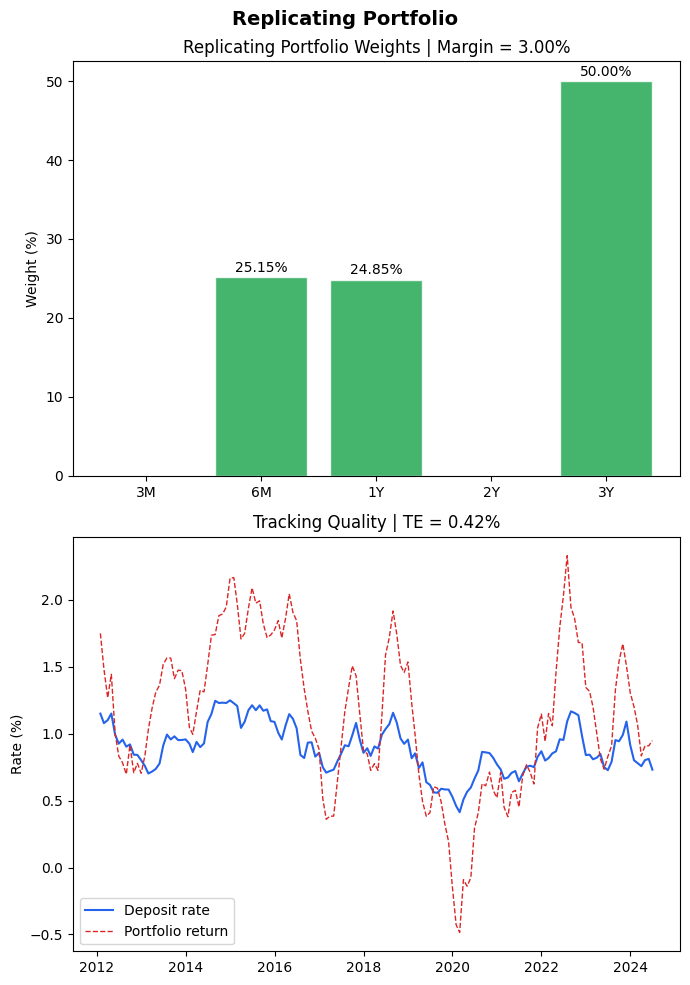

In [12]:
# Plot replicating portfolio
plot_replicate_port(
    rep_result = rep_result,
    deposit_rate = deposit_rate
)

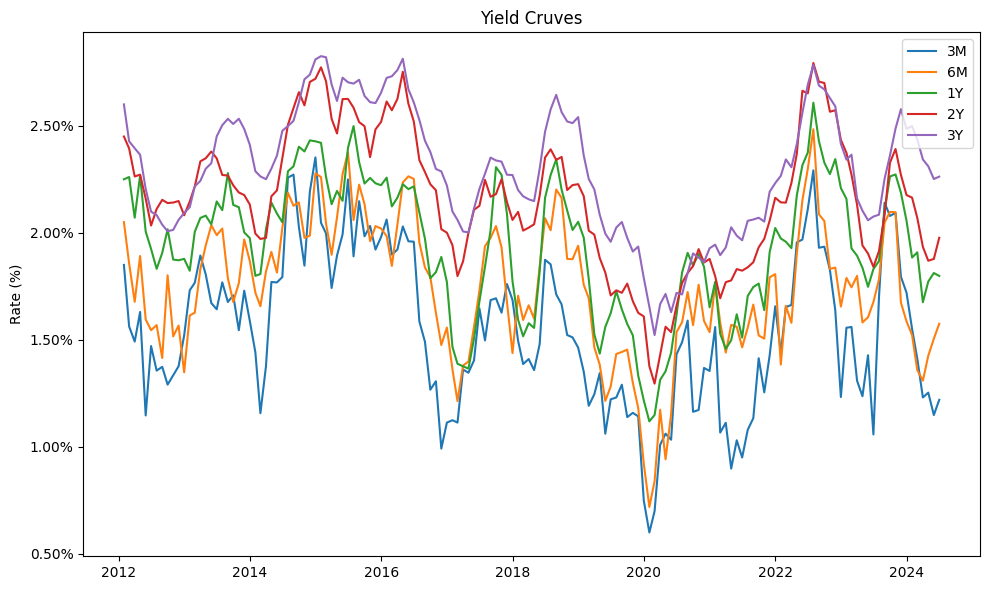

In [13]:
# Plot yield curves
plt.figure(figsize = (10, 6))
plt.plot(yield_curve, label = yield_curve.columns)
plt.gca().yaxis.set_major_formatter(PercentFormatter(2.0)) 
plt.ylabel("Rate (%)")
plt.title("Yield Cruves")
plt.legend(loc = "upper right")
plt.tight_layout()
plt.show()

In [ ]:
# Full yield curves
yield_curve_full = build_yield_curve(
    market_rate = market_rate,
    tenors_years = [0.25, 0.5, 1, 2, 3, 5, 10]
)

# Export
with open("../model/yield_curve.pkl", "wb") as file:
    pickle.dump(yield_curve_full, file)